# Canada fires:

In [1]:
import zipfile
import tempfile
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
from tableauhyperapi import HyperProcess, Telemetry, Connection

TWBX_PATH = Path.home() / "Courses/EPS101/Data-for-teaching-staff/Forest-fires/Canada-fires" / "3 - Landing Page Fires by area and number.twbx"

def read_series(hyper_path, value_col):
    with HyperProcess(
        Telemetry.DO_NOT_SEND_USAGE_DATA_TO_TABLEAU,
        parameters={"log_config": ""}
    ) as hyper:
        with Connection(endpoint=hyper.endpoint, database=str(hyper_path)) as connection:
            rows = connection.execute_list_query(f'''
                SELECT "Year", SUM("{value_col}")
                FROM "Extract"."Extract"
                GROUP BY 1
                ORDER BY 1
            ''')
    return np.array([int(y) for y, _ in rows]), np.array([float(v) for _, v in rows])

with tempfile.TemporaryDirectory() as tmp:
    tmp = Path(tmp)
    with zipfile.ZipFile(TWBX_PATH) as zf:
        zf.extractall(tmp)

    hyper_files = sorted(tmp.rglob("*.hyper"))

    Canada_fire_number_years, Canada_fire_number = read_series(hyper_files[0], "Number")
    Canada_fire_area_years, Canada_fire_area = read_series(hyper_files[1], "Area (hectares)")
    Canada_fire_area = Canada_fire_area / 100.0

print("done.")

done.


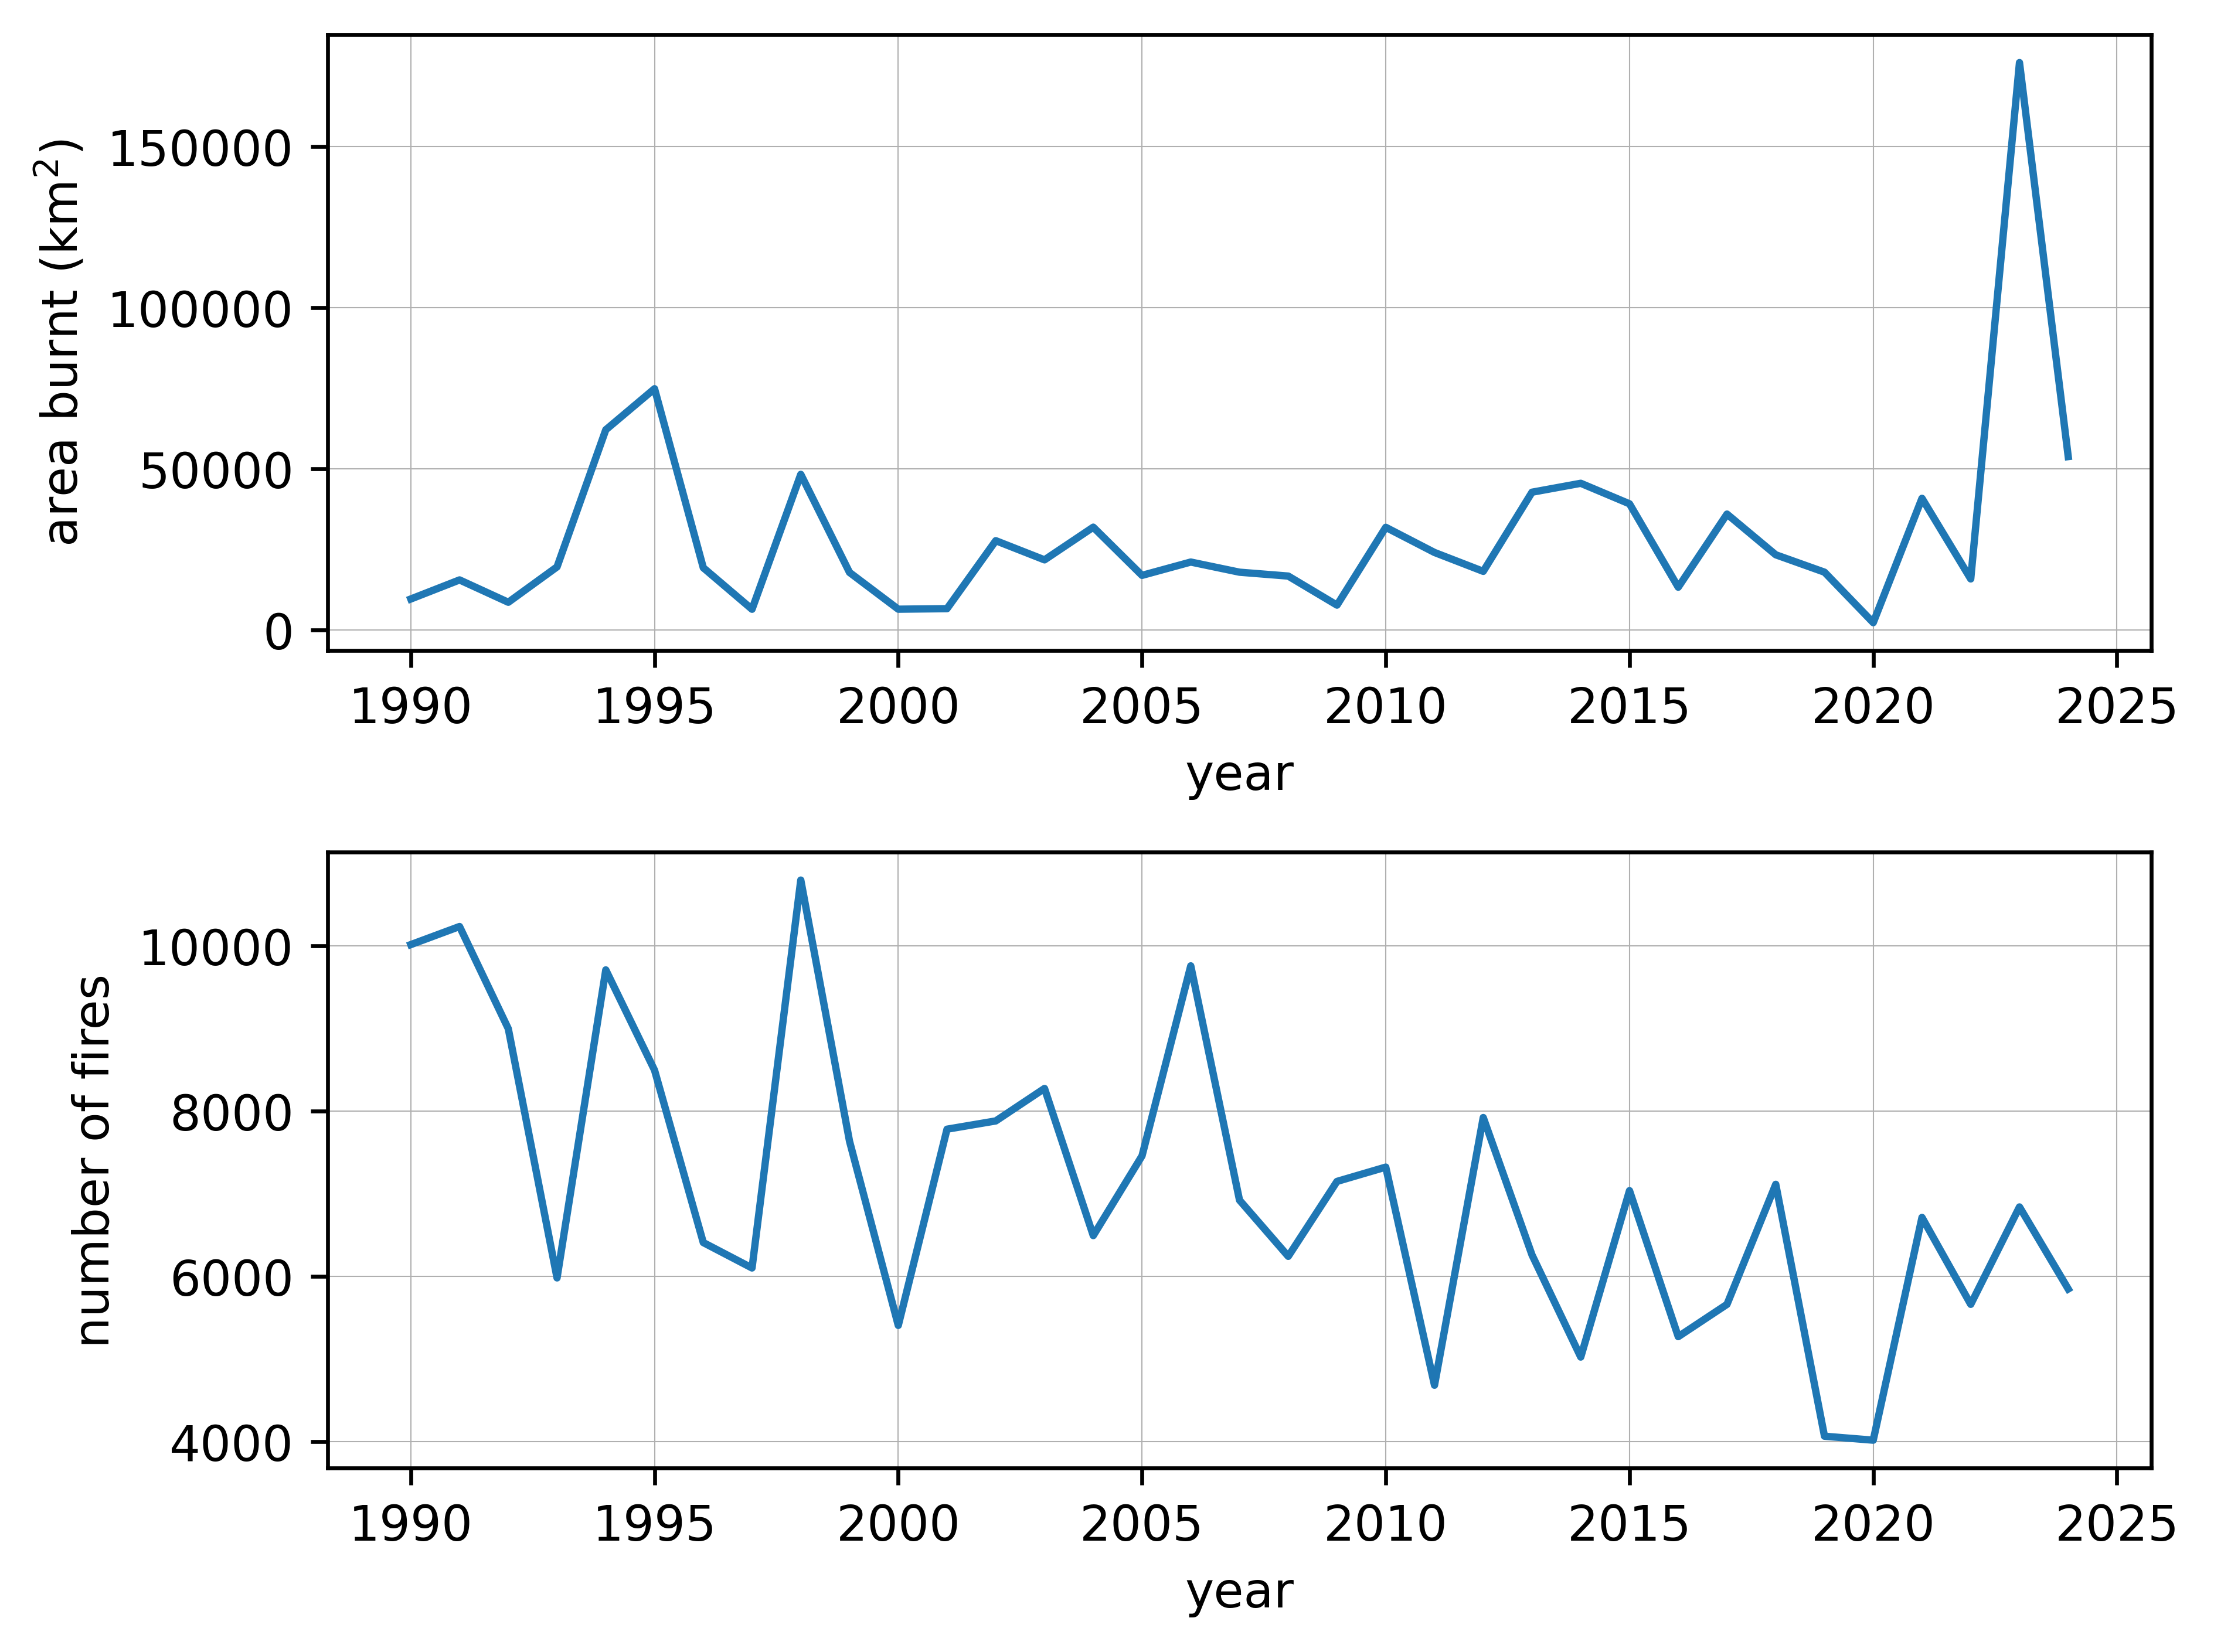

In [2]:
# plot:
plt.figure(dpi=600)
plt.subplot(2,1,1)
plt.plot(Canada_fire_area_years,Canada_fire_area)
plt.xlabel("year")
plt.ylabel("area burnt (km$^2$)")
plt.grid(lw=0.25)

plt.subplot(2,1,2)
plt.plot(Canada_fire_number_years,Canada_fire_number)
plt.xlabel("year")
plt.ylabel("number of fires")
plt.grid(lw=0.25)

plt.tight_layout()

In [3]:
np.save("Output/to-pickle/canada_fire_years",Canada_fire_area_years)
np.save("Output/to-pickle/canada_fire_area",Canada_fire_area)
np.save("Output/to-pickle/canada_fire_number",Canada_fire_number)
print("done.")

done.
